<a href="https://colab.research.google.com/github/welmi496/Neural-Network-and-Deep-Learning-Basics/blob/main/Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with a Feedforward Neural Network on CIFAR-10

**Course Assignment Submission**

This notebook follows the assignment requirements exactly:
- CIFAR-10 dataset loaded with TensorFlow/Keras
- sample image visualization
- normalization of image values to the range 0 to 1
- feedforward neural network with ReLU and Softmax
- Adam optimizer, categorical crossentropy, and accuracy
- training, evaluation, confusion matrix, precision, recall, and F1-score
- comparison of a baseline model and an improved model
- discussion of a practical application scenario

## 1. Introduction

CIFAR-10 is a labeled image dataset containing 60,000 color images of size 32 x 32 across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. It is a suitable dataset for image classification because it contains everyday objects and visually similar categories, which makes classification more challenging and more meaningful for neural network learning.

In this assignment, a feedforward neural network is used to classify CIFAR-10 images. The notebook also compares a baseline network with an improved version to examine how architectural changes affect performance.

In [1]:
# 2. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

# Reproducibility
np.random.seed(42)

In [2]:
# 3. Load the Dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('Training images shape:', X_train.shape)
print('Training labels shape:', y_train.shape)
print('Test images shape:', X_test.shape)
print('Test labels shape:', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


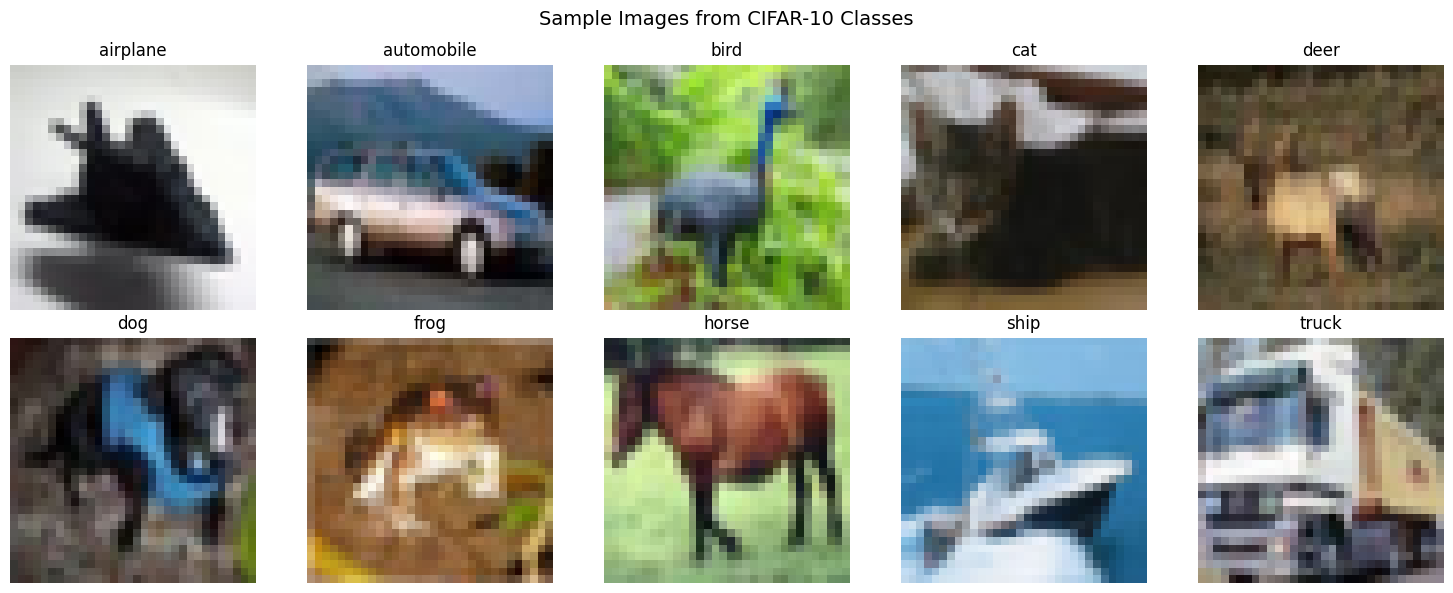

In [3]:
# 4. Visualize One Sample Image from Each Class

plt.figure(figsize=(15, 6))
selected_indexes = []

for class_id in range(10):
    idx = np.where(y_train.flatten() == class_id)[0][0]
    selected_indexes.append(idx)
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.suptitle('Sample Images from CIFAR-10 Classes', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Methodology

The preprocessing step normalizes pixel values by dividing by 255 so that all values are between 0 and 1. The labels are converted to one-hot encoded vectors because the task is a multi-class classification problem.

Two feedforward neural networks are trained:
1. **Baseline model** with one hidden layer.
2. **Improved model** with more layers, dropout, and batch normalization.

Both models use:
- ReLU activation in hidden layers
- Softmax activation in the output layer
- Adam optimizer
- Categorical crossentropy loss
- Accuracy as the training metric

In [4]:
# 5. Preprocess the Data

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print('Pixel value range after normalization:')
print('Min:', X_train.min(), 'Max:', X_train.max())
print('One-hot encoded label shape:', y_train_cat.shape)

Pixel value range after normalization:
Min: 0.0 Max: 1.0
One-hot encoded label shape: (50000, 10)


In [5]:
# 6. Build the Baseline Feedforward Neural Network

baseline_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 7. Train the Baseline Model

EPOCHS = 15
BATCH_SIZE = 64

history_baseline = baseline_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.3254 - loss: 1.9146 - val_accuracy: 0.3586 - val_loss: 1.7899
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3870 - loss: 1.7240 - val_accuracy: 0.3788 - val_loss: 1.7322
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.4089 - loss: 1.6571 - val_accuracy: 0.4142 - val_loss: 1.6667
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4331 - loss: 1.5978 - val_accuracy: 0.4282 - val_loss: 1.6014
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4475 - loss: 1.5573 - val_accuracy: 0.4212 - val_loss: 1.6169
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4592 - loss: 1.5279 - val_accuracy: 0.4580 - val_loss: 1.5282
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4644 - loss: 1.5047 - val_accuracy: 0.4540 - val_loss: 1.5366
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4754 - loss: 1.4791 - 

In [7]:
# 8. Evaluate the Baseline Model

baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Baseline Test Loss: {baseline_loss:.4f}')
print(f'Baseline Test Accuracy: {baseline_accuracy:.4f}')

Baseline Test Loss: 1.4827
Baseline Test Accuracy: 0.4817


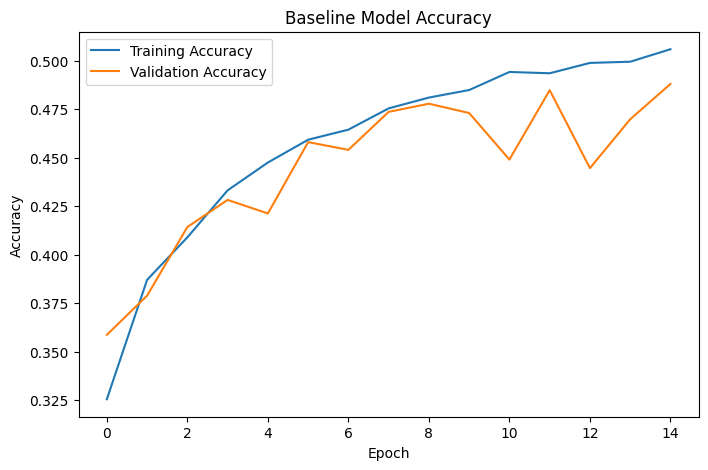

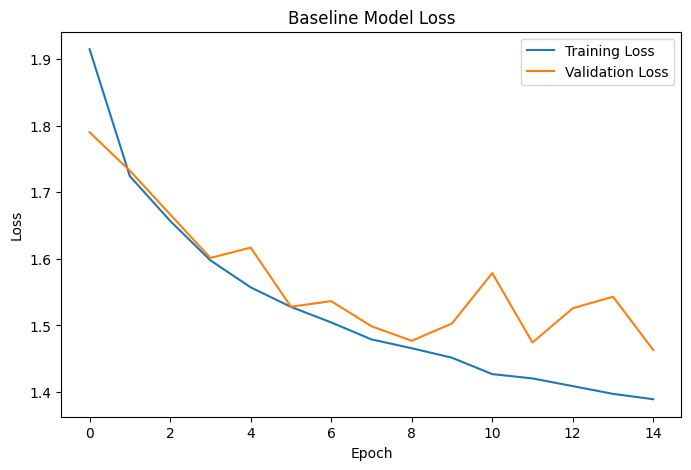

In [8]:
# 9. Plot Baseline Training History

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Baseline Classification Report:
              precision    recall  f1-score   support

    airplane       0.55      0.53      0.54      1000
  automobile       0.56      0.66      0.61      1000
        bird       0.34      0.39      0.36      1000
         cat       0.30      0.38      0.34      1000
        deer       0.56      0.28      0.37      1000
         dog       0.38      0.39      0.38      1000
        frog       0.49      0.63      0.55      1000
       horse       0.62      0.47      0.53      1000
        ship       0.66      0.54      0.59      1000
       truck       0.51      0.57      0.54      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.48     10000
weighted avg       0.50      0.48      0.48     10000



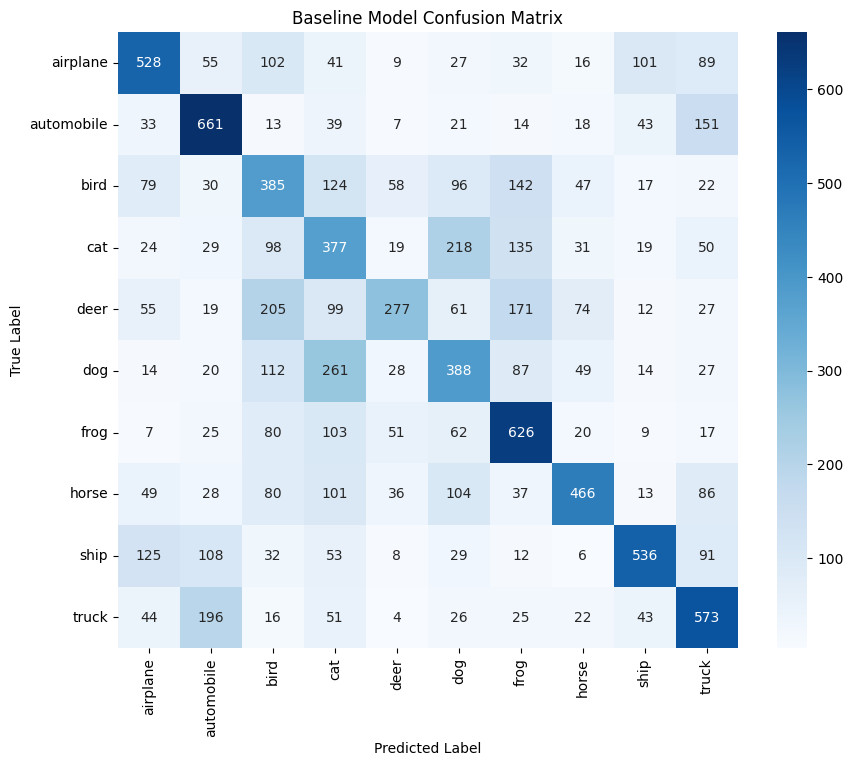

In [9]:
# 10. Baseline Predictions, Classification Report, and Confusion Matrix

y_pred_baseline_prob = baseline_model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_pred_baseline_prob, axis=1)
y_true = y_test.flatten()

print('Baseline Classification Report:')
print(classification_report(y_true, y_pred_baseline, target_names=class_names))

cm_baseline = confusion_matrix(y_true, y_pred_baseline)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [10]:
# 11. Build the Improved Feedforward Neural Network

improved_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811,594 (14.54 MB)

 Trainable params: 3,808,522 (14.53 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [11]:
# 12. Train the Improved Model

history_improved = improved_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 86ms/step - accuracy: 0.3411 - loss: 1.8883 - val_accuracy: 0.3286 - val_loss: 1.8797
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.4065 - loss: 1.6630 - val_accuracy: 0.3618 - val_loss: 1.7996
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.4274 - loss: 1.6053 - val_accuracy: 0.4192 - val_loss: 1.5958
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.4359 - loss: 1.5685 - val_accuracy: 0.4236 - val_loss: 1.6550
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.4398 - loss: 1.5655 - val_accuracy: 0.4586 - val_loss: 1.5134
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.4503 - loss: 1.5374 - val_accuracy: 0.3912 - val_loss: 1.7096
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.4552 - loss: 1.5204 - val_accuracy: 0.4580 - val_loss: 1.5155
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 73ms/step - accuracy: 0.4620 - loss: 1.4980 - 

In [12]:
# 13. Evaluate the Improved Model

improved_loss, improved_accuracy = improved_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Improved Test Loss: {improved_loss:.4f}')
print(f'Improved Test Accuracy: {improved_accuracy:.4f}')

Improved Test Loss: 1.4116
Improved Test Accuracy: 0.4963


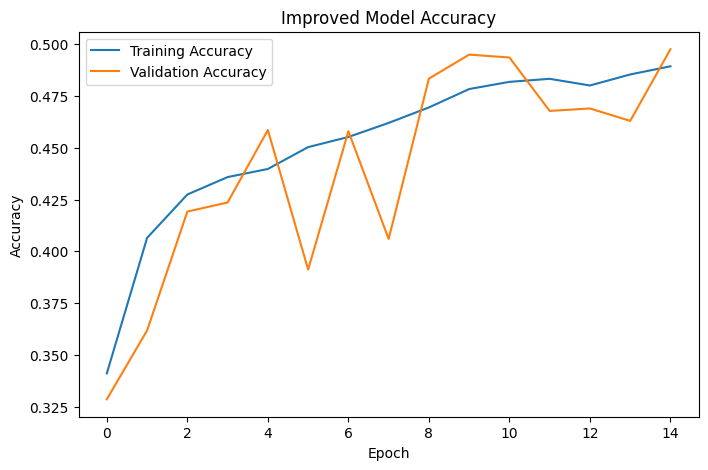

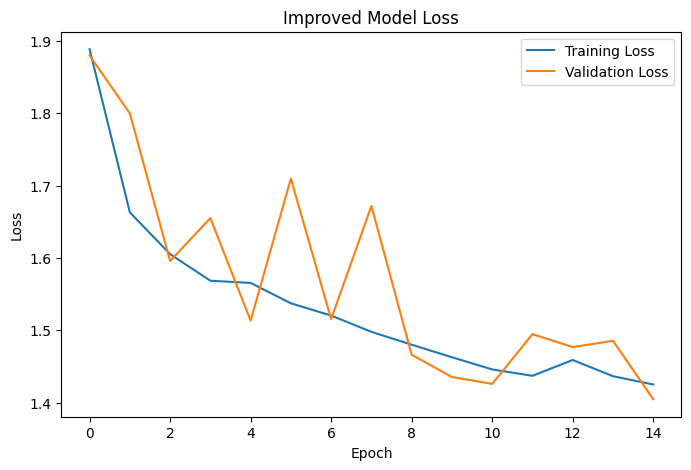

In [13]:
# 14. Plot Improved Training History

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Improved Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Improved Classification Report:
              precision    recall  f1-score   support

    airplane       0.57      0.54      0.55      1000
  automobile       0.63      0.62      0.63      1000
        bird       0.41      0.32      0.36      1000
         cat       0.34      0.37      0.36      1000
        deer       0.45      0.42      0.44      1000
         dog       0.43      0.38      0.40      1000
        frog       0.46      0.62      0.53      1000
       horse       0.56      0.54      0.55      1000
        ship       0.51      0.74      0.60      1000
       truck       0.64      0.41      0.50      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



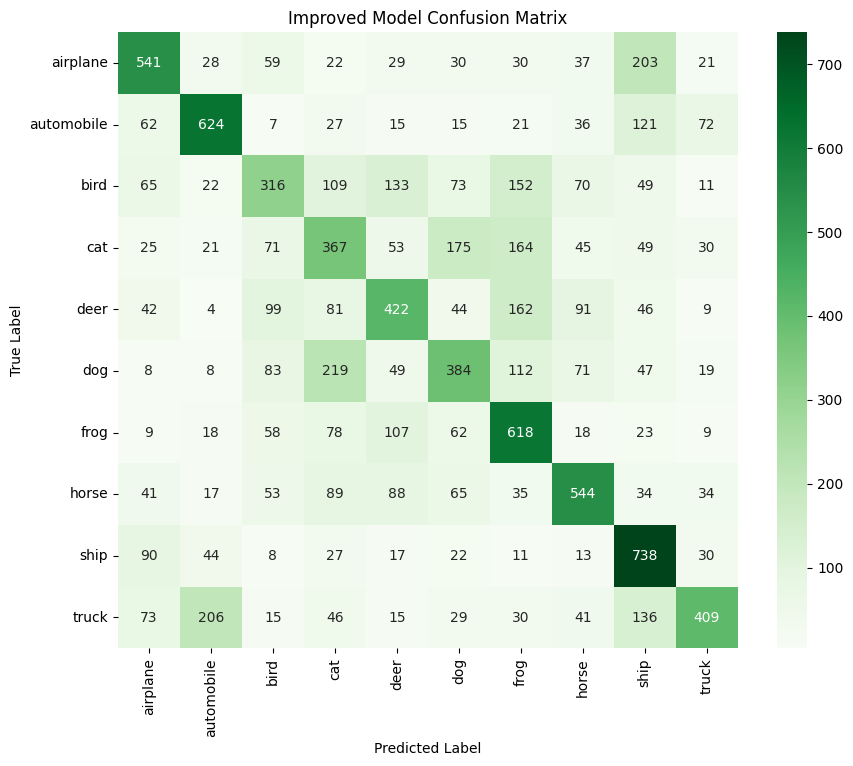

In [14]:
# 15. Improved Predictions, Classification Report, and Confusion Matrix

y_pred_improved_prob = improved_model.predict(X_test, verbose=0)
y_pred_improved = np.argmax(y_pred_improved_prob, axis=1)

print('Improved Classification Report:')
print(classification_report(y_true, y_pred_improved, target_names=class_names))

cm_improved = confusion_matrix(y_true, y_pred_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Improved Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# 16. Compare Final Metrics of Both Models

precision_b, recall_b, f1_b, _ = precision_recall_fscore_support(
    y_true, y_pred_baseline, average='weighted', zero_division=0
)
precision_i, recall_i, f1_i, _ = precision_recall_fscore_support(
    y_true, y_pred_improved, average='weighted', zero_division=0
)

comparison_df = pd.DataFrame({
    'Model': ['Baseline FFNN', 'Improved FFNN'],
    'Accuracy': [accuracy_score(y_true, y_pred_baseline), accuracy_score(y_true, y_pred_improved)],
    'Precision': [precision_b, precision_i],
    'Recall': [recall_b, recall_i],
    'F1-Score': [f1_b, f1_i]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline FFNN,0.4817,0.497438,0.4817,0.481046
1,Improved FFNN,0.4963,0.500387,0.4963,0.491832


## 3. Results Analysis

After running the notebook, use the generated output to discuss:
- training and validation accuracy trends
- training and validation loss trends
- differences between the baseline and improved models
- which classes are classified well and which are confused in the confusion matrix
- how the improved architecture changes the final performance metrics

## 4. Practical Application Scenario

A practical application for this model is **digital media organization**. For example, a media platform could automatically tag uploaded images into categories such as airplane, automobile, ship, truck, bird, or dog. This would improve search, filtering, and automatic album organization.

### Operational Challenges
- **Scalability:** a production system would need to classify large volumes of images efficiently.
- **Real-time processing:** response time must be fast if classification happens during upload.
- **Integration:** the model must work with cloud storage, metadata systems, and application APIs.
- **Model limitations:** CIFAR-10 images are small, so a production system would need retraining on larger and more realistic images.

## 5. Conclusion

This assignment demonstrates how a feedforward neural network can be used for image classification on CIFAR-10. The preprocessing step normalizes image data and prepares the labels for multi-class learning. The improved model is expected to perform better than the baseline because of its additional layers, regularization, and normalization.

Future improvements for this task could include convolutional neural networks, larger image inputs, and more advanced regularization strategies. However, this notebook stays within the assignment requirement by using a neural network structure based on dense layers.